# Example Script

Baseline Ito (alpha=0) comparison.

Run this as a script or interactively with cell markers.
To run from this directory: python baseline_ito_comparison.py

Compares DTO, PINN, and BiLO on a shared synthetic field problem and plots
diagnostics.

### Cell 1: Setup


In [2]:
import numpy as np
import torch

from interface import Problem, solve, show_settings
import diagnostics

### Cell 2: Settings (shared + field)


In [3]:
# Note: many options are left at defaults (see show_settings() for the full list).

# show_settings()
# NOTE: when configs are merged with **{...}, later dicts override earlier keys.
# Optional knobs left at defaults here: use_ddi, w_data, log_every, use_rff_geom/use_rff_logd.
SHARED_CONFIG = {
    "max_iters": 10000,
    "lr_d": 1e-4,
    "wreg_smooth": 1e-5,  # weak regularization
    "wreg_scale": 1e-5,
    "smoothness_type": "h1",  # or 'tv'
    "pert_scale": 0.25,  # relative D_init amplitude for pretrain (renamed from d_init_scale)
    "pert_freq": 2.0,    # D_init oscillation frequency (renamed from d_init_freq)
    "scalar_fit_iters": 500,  # NEW: scalar fit phase to find optimal D scale
    "use_scheduler": True,
    "early_burnin": 2500,
    "early_patience": 500,
    "early_tol": 1e-4,  # relative to total loss
    "n_res": 201,
}

DTO_FIELD_CONFIG = {
    "field_loss": "rle",  # field-mode data loss
    "pert_scale": 0.0,    # DTO doesn't need wiggles (no neural operator)
}

PINN_FIELD_CONFIG = {
    "pretrain_iters": 2000,
    "field_loss": "rle",  # field-mode data loss
    "lr_lower": 1e-4,
    "w_phys": 1.0,
    "w_jump": 1.0,
    "use_rff": True,
}

BILO_FIELD_CONFIG = {
    "pretrain_iters": 2000,
    "field_loss": "rle",  # field-mode data loss
    "lr_lower": 1e-4,
    "lr_d": 2e-5, # 1e-4
    "w_jump": 1.0,
    "w_resgrad": 1e-1,
    "use_rff": True,
    "early_tol": 1e-6,  # BILO needs stricter early stop for some reason
}

### Cell 3: Create problem


In [4]:
# Synthetic problem with explicit physics parameters
problem = Problem.synthetic(
    alpha=0.0,  # Ito convention
    mode="field",  # "field" uses dense u(x)
    d_profile="sinusoidal",  # D(x) profile family
    d_profile_params=(0.1, 0.04, 4.0),  # (mean, amplitude, frequency)
    mu=5.0,  # death rate
    source_location=0.5,  # point source location
    b_true=100.0,  # source strength
    n_obs=201,  # observation grid
    seed=42,  # RNG seed
)

print(
    f"[Synthetic] α: {problem.alpha} | μ: {problem.mu} | b₀: {problem.b_true} | "
    f"Grid: {len(problem.x_grid)} pts"
)
mean_d_true = float(np.mean(problem.d_true)) if problem.d_true is not None else None

[Problem] Field: ∫u 1.899e+01 | ⟨D⟩_true: 1.000e-01
[Synthetic] α: 0.0 | μ: 5.0 | b₀: 100.0 | Grid: 201 pts


### Cell 4: DTO



--- DTO ---
[Solve] Method: DTO | α: 0.0 | Mode: field
[scalar_fit] Starting: d_init=0.068306, mode=field, max_iters=500
[scalar_fit] iter 0: D=0.168306, loss=8.364007e-02
[scalar_fit] iter 100: D=0.090647, loss=6.749520e-02
[scalar_fit] iter 200: D=0.090447, loss=6.749333e-02
[scalar_fit] iter 300: D=0.090445, loss=6.749333e-02
[scalar_fit] iter 400: D=0.090445, loss=6.749333e-02
[scalar_fit] Final: D=0.090445, loss=6.749333e-02
[DTO] DDI scale: 6.831e-02
[DTO] Scalar fit scale: 9.044e-02
[DTO] Iter 00000 | Ltot: 6.749e-02
  Ldata(rle): 6.749e-02 | RegSmooth: 0.000e+00 (eff: 0.000e+00) | RegScale: 0.000e+00 (eff: 0.000e+00)
  b0*: 86.92 | int_u_hat: 1.903e-01 | int_u: 1.654e+01 | mean_D: 9.044e-02
[DTO] Iter 00200 | Ltot: 1.457e-02
  Ldata(rle): 1.457e-02 | RegSmooth: 1.839e-01 (eff: 1.839e-06) | RegScale: 2.334e-04 (eff: 2.334e-09)
  b0*: 96.30 | int_u_hat: 1.909e-01 | int_u: 1.838e+01 | mean_D: 8.977e-02
[DTO] Iter 00400 | Ltot: 1.450e-03
  Ldata(rle): 1.447e-03 | RegSmooth: 3.291e

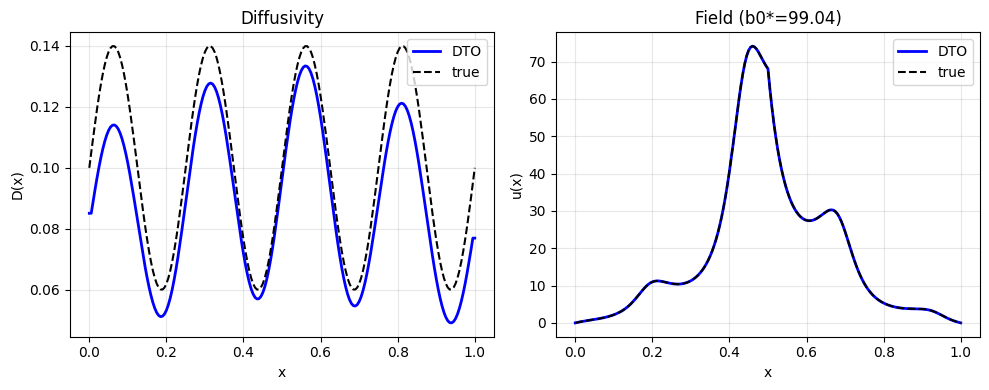

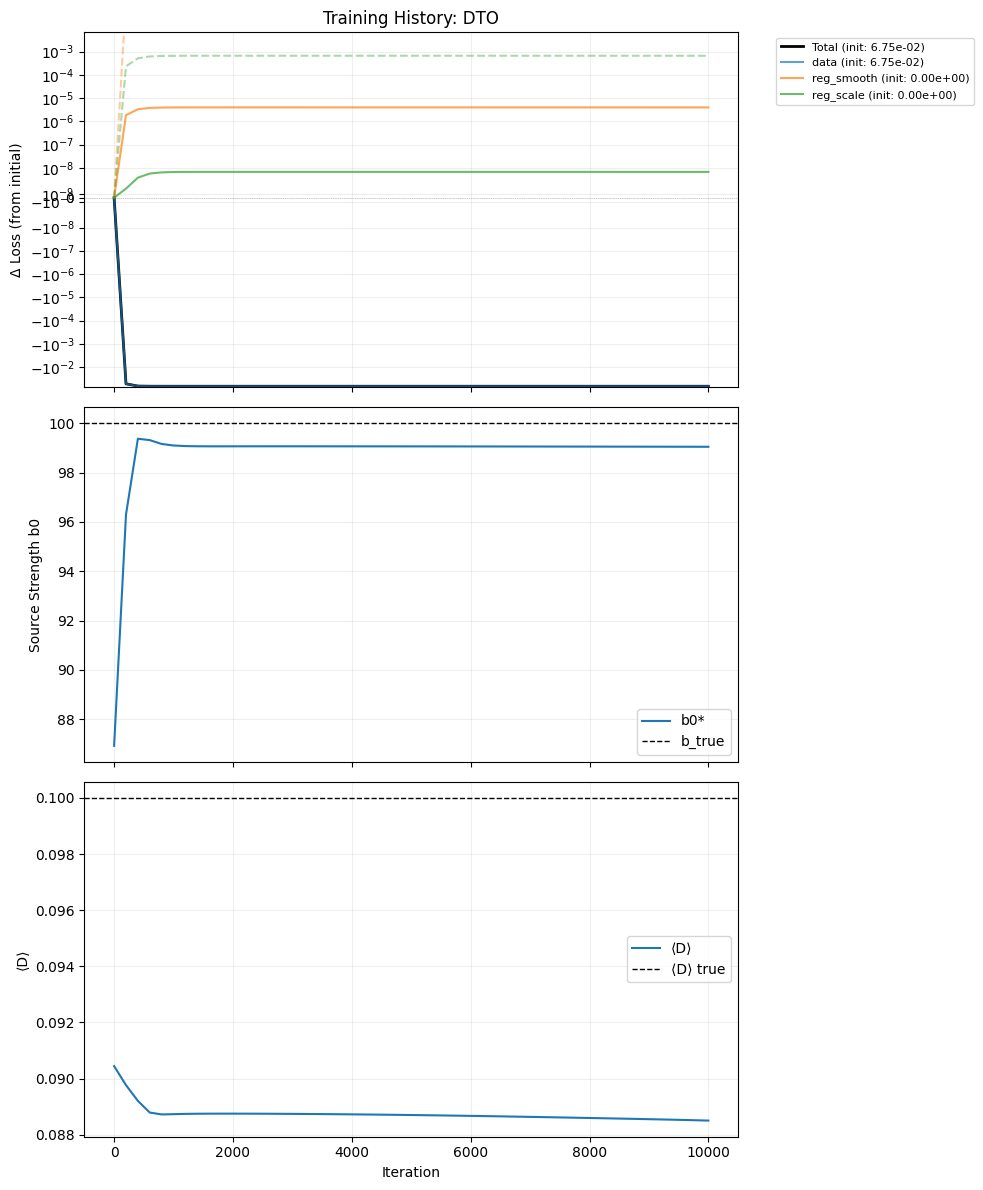

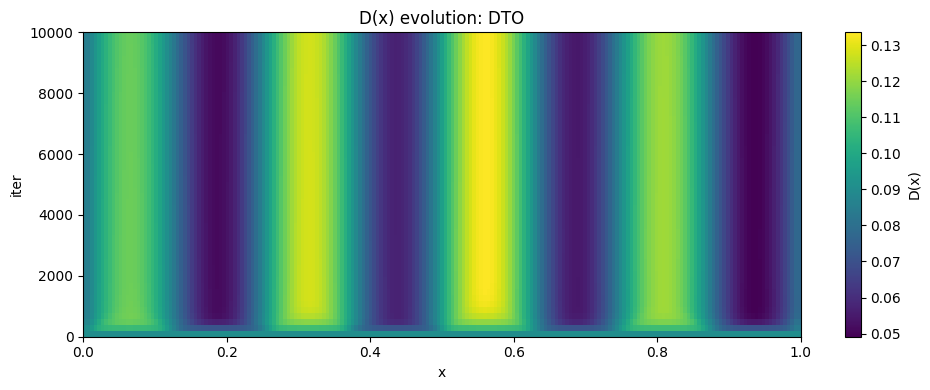

In [5]:
print("\n--- DTO ---")
# DTO (Discretize-Then-Optimize) options (field mode).
dto_solution = solve(
    problem,
    method="dto",  # discretize-then-optimize solver
    **{**SHARED_CONFIG, **DTO_FIELD_CONFIG},
)
dto_metrics = dto_solution.metrics(problem)
print(f"DTO: D(x) rel error = {dto_metrics['d_rel_error']:.2%}, b0* = {dto_solution.b0_star:.2f}")
dto_solution.plot(problem)
diagnostics.plot_training_history(
    "DTO",
    dto_solution.history,
    problem.b_true,
    outdir=None,
    mean_d_true=mean_d_true,
    weights=dto_solution.weights,
)
diagnostics.plot_d_evolution(
    "DTO",
    dto_solution.history,
    dto_solution.x_res.detach().cpu().numpy().reshape(-1),
    outdir=None,
    mean_d_true=mean_d_true,
)


### Cell 5: PINN



--- PINN ---
[Solve] Method: PINN | α: 0.0 | Mode: field
[scalar_fit] Starting: d_init=0.068306, mode=field, max_iters=500
[scalar_fit] iter 0: D=0.168306, loss=8.364007e-02
[scalar_fit] iter 100: D=0.090647, loss=6.749520e-02
[scalar_fit] iter 200: D=0.090447, loss=6.749333e-02
[scalar_fit] iter 300: D=0.090445, loss=6.749333e-02
[scalar_fit] iter 400: D=0.090445, loss=6.749333e-02
[scalar_fit] Final: D=0.090445, loss=6.749333e-02
[PINN] DDI scale: 6.831e-02
[PINN] Scalar fit scale: 9.044e-02
[PINN|pretrain] Iter 00000 | Ltot: 3.769e+00
  Lphys: 3.436e+00 | Lanchor: 3.339e-01
  Lres: 2.432e+00 | Ljump: 1.003e+00
  mean_D: 6.682e-01
[PINN|pretrain] Iter 00200 | Ltot: 2.136e-01
  Lphys: 1.284e-01 | Lanchor: 8.523e-02
  Lres: 5.385e-02 | Ljump: 7.455e-02
  mean_D: 3.701e-01
[PINN|pretrain] Iter 00400 | Ltot: 1.743e-02
  Lphys: 5.390e-03 | Lanchor: 1.203e-02
  Lres: 5.150e-03 | Ljump: 2.404e-04
  mean_D: 1.979e-01
[PINN|pretrain] Iter 00600 | Ltot: 3.837e-03
  Lphys: 6.132e-04 | Lanchor:

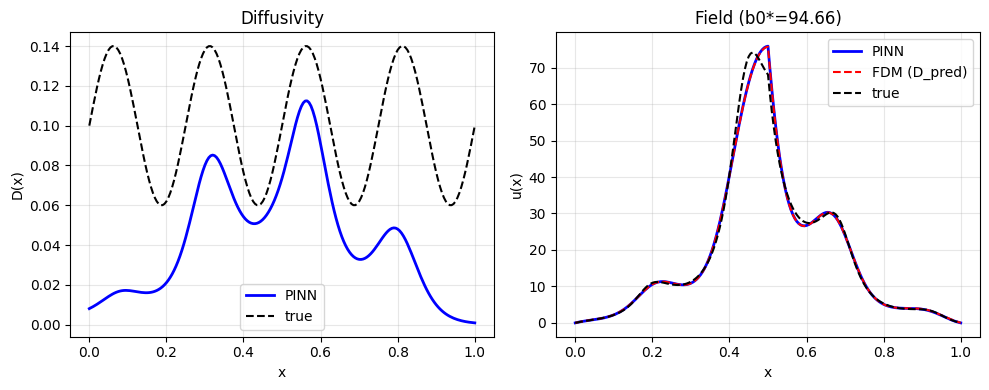

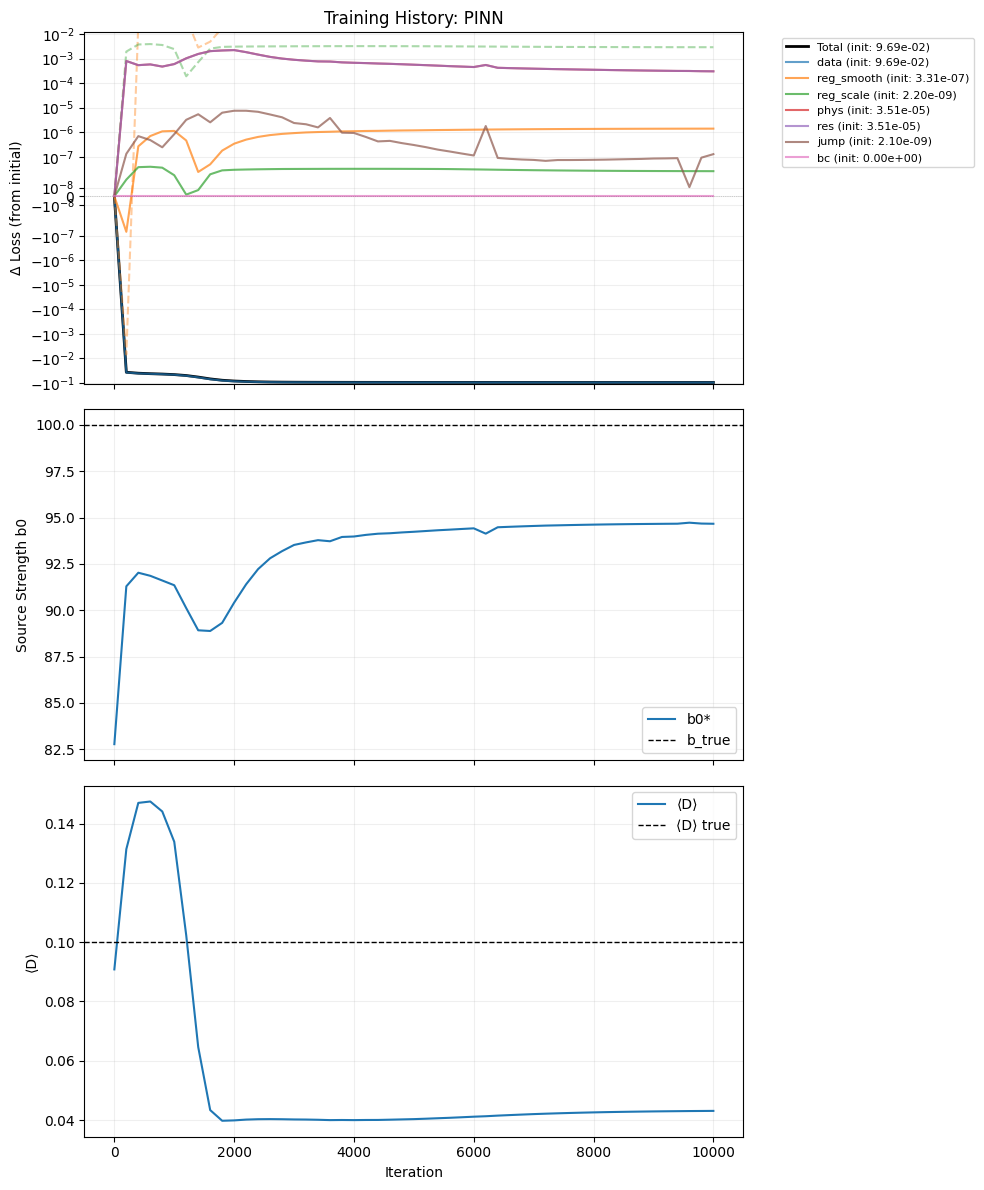

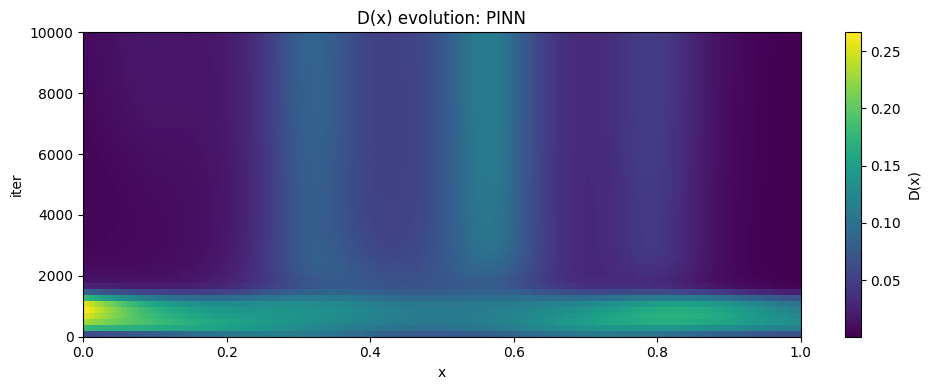

In [6]:
print("\n--- PINN ---")
# PINN (Physics-Informed Neural Network) options (field mode).
pinn_solution = solve(
    problem,
    method="pinn",  # physics-informed neural network
    **{**SHARED_CONFIG, **PINN_FIELD_CONFIG},
)
pinn_metrics = pinn_solution.metrics(problem)
print(f"PINN: D(x) rel error = {pinn_metrics['d_rel_error']:.2%}, b0* = {pinn_solution.b0_star:.2f}")
pinn_solution.plot(problem)
diagnostics.plot_training_history(
    "PINN",
    pinn_solution.history,
    problem.b_true,
    outdir=None,
    mean_d_true=mean_d_true,
    weights=pinn_solution.weights,
)
diagnostics.plot_d_evolution(
    "PINN",
    pinn_solution.history,
    pinn_solution.x_res.detach().cpu().numpy().reshape(-1),
    outdir=None,
    mean_d_true=mean_d_true,
)


### Cell 6: BiLO



--- BiLO ---
[Solve] Method: BILO | α: 0.0 | Mode: field
[scalar_fit] Starting: d_init=0.068306, mode=field, max_iters=500
[scalar_fit] iter 0: D=0.168306, loss=8.364007e-02
[scalar_fit] iter 100: D=0.090647, loss=6.749520e-02
[scalar_fit] iter 200: D=0.090447, loss=6.749333e-02
[scalar_fit] iter 300: D=0.090445, loss=6.749333e-02
[scalar_fit] iter 400: D=0.090445, loss=6.749333e-02
[scalar_fit] Final: D=0.090445, loss=6.749333e-02
[BiLO] DDI scale: 6.831e-02
[BiLO] Scalar fit scale: 9.044e-02
[BiLO|pretrain] Iter 00000 | Ltot: 3.967e+00
  Lanchor: 4.355e-01 | Llower: 3.499e+00 | Lsup: 3.224e-02
  Lres: 2.400e+00 | Ljump: 9.993e-01 | Lrgrad: 9.978e-01 | Ljump_rgrad: 8.469e-08
  mean_D: 7.487e-01
[BiLO|pretrain] Iter 00200 | Ltot: 4.000e-01
  Lanchor: 1.923e-01 | Llower: 1.763e-01 | Lsup: 3.134e-02
  Lres: 5.103e-02 | Ljump: 7.413e-02 | Lrgrad: 1.590e-01 | Ljump_rgrad: 3.526e-01
  mean_D: 5.250e-01
[BiLO|pretrain] Iter 00400 | Ltot: 1.138e-01
  Lanchor: 5.422e-02 | Llower: 4.946e-02 | 

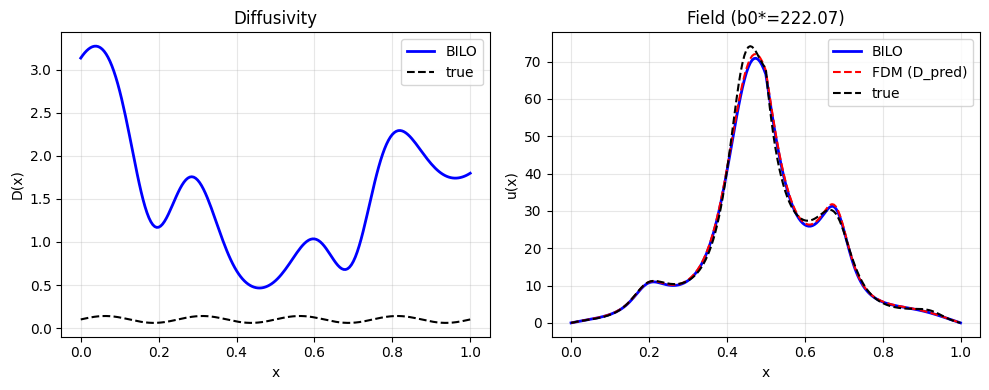

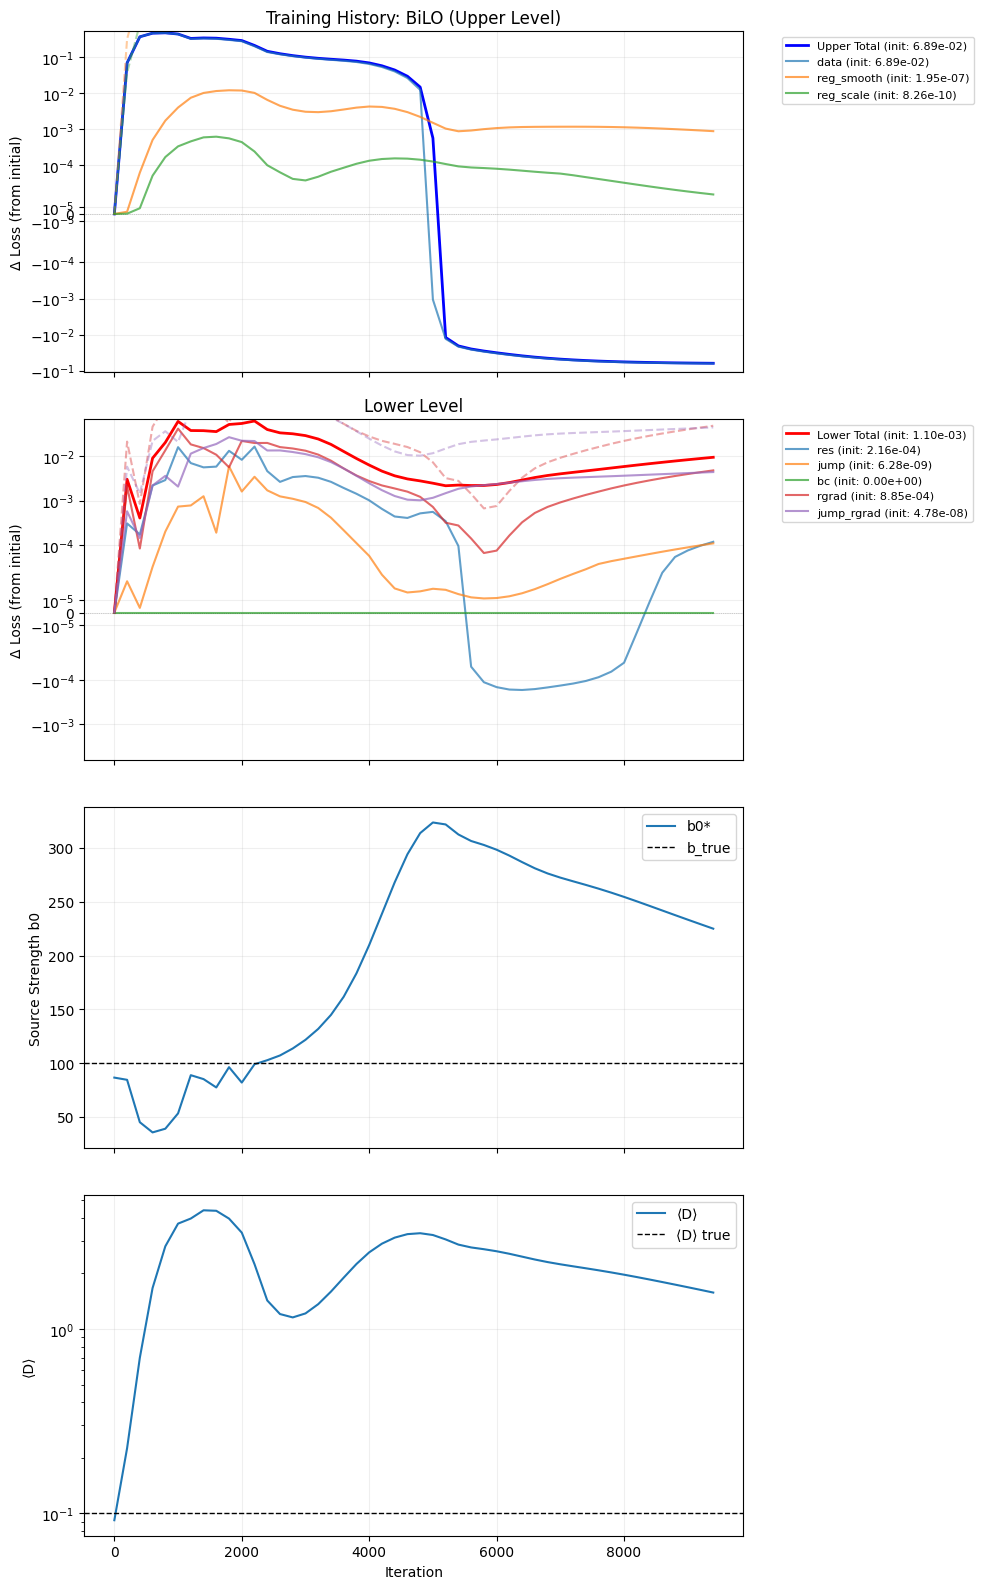

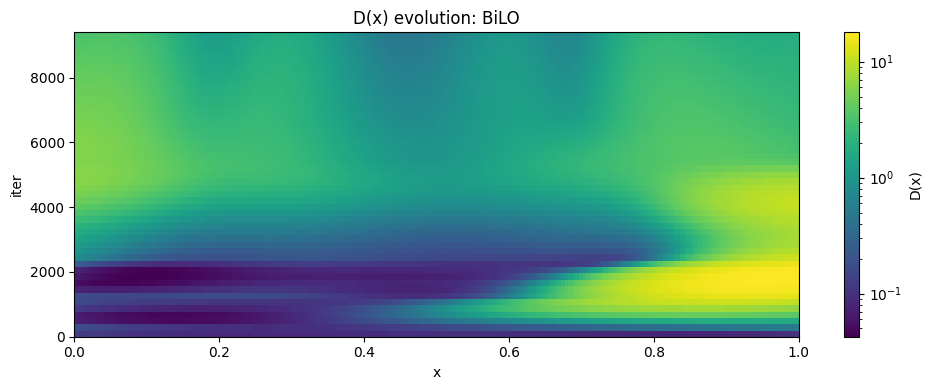

In [7]:
print("\n--- BiLO ---")
# BiLO (Bilevel Optimization) options (field mode).
bilo_solution = solve(
    problem,
    method="bilo",  # bilevel local operator
    **{**SHARED_CONFIG, **BILO_FIELD_CONFIG},
)
bilo_metrics = bilo_solution.metrics(problem)
print(f"BiLO: D(x) rel error = {bilo_metrics['d_rel_error']:.2%}, b0* = {bilo_solution.b0_star:.2f}")
bilo_solution.plot(problem)
diagnostics.plot_training_history(
    "BiLO",
    bilo_solution.history,
    problem.b_true,
    outdir=None,
    mean_d_true=mean_d_true,
    weights=bilo_solution.weights,
)
diagnostics.plot_d_evolution(
    "BiLO",
    bilo_solution.history,
    bilo_solution.x_res.detach().cpu().numpy().reshape(-1),
    outdir=None,
    mean_d_true=mean_d_true,
)


### Cell 7: Particle settings


In [8]:
DTO_PARTICLE_CONFIG = {
    "wreg_smooth": 1e-2, # stronger regularization for particles
}

PINN_PARTICLE_CONFIG = {
    "pretrain_iters": 1000,
    "wreg_smooth": 1e-2, # stronger regularization for particles
    "lr_lower": 1e-4,
    "w_phys": 10.0,
    "w_jump": 1e-1,
    "use_rff": True,
}

BILO_PARTICLE_CONFIG = {
    "pretrain_iters": 3000, # pretrain more so jump loss ->0 too
    "wreg_smooth": 1e-4, # stronger? regularization for particles
    "wreg_scale": 1e-4, # stronger? regularization for particles
    "lr_lower": 1e-4,
    "w_jump": 1.0,
    "w_resgrad": 0.01, # not sure what to set this
    "use_rff": True,
    "early_tol": 1e-6, # bilo stops early for some odd reason i cant figure out 
}


# Generate particle data

In [9]:
print("\n--- Particle Mode Setup ---")
problem_ppp = Problem.synthetic(
    alpha=0.0,  # Ito convention
    mode="particles",  # particle PPP observations
    d_profile="sinusoidal",  # D(x) profile family
    d_profile_params=(0.1, 0.04, 4.0),  # (mean, amplitude, frequency)
    mu=5.0,  # death rate
    source_location=0.5,  # point source location
    b_true=100.0,  # source strength
    m_obs=1000,  # PPP snapshots
    use_pde_sampling=True,  # sample PPP from PDE field instead of SDE
    seed=42,  # RNG seed
)


mean_d_true_ppp = float(np.mean(problem_ppp.d_true)) if problem_ppp.d_true is not None else None


--- Particle Mode Setup ---
[Problem] Particles: n_obs 19095 | m_obs 1000 | ⟨n⟩/obs 19.09 | ⟨D⟩_true: 1.000e-01


### Cell 7: Particle observations (DTO)



--- DTO (particles) ---
[Solve] Method: DTO | α: 0.0 | Mode: particles
[scalar_fit] Starting: d_init=0.068715, mode=particles, max_iters=500
[scalar_fit] iter 0: D=0.168715, loss=-8.850678e+00
[scalar_fit] iter 100: D=0.094629, loss=-8.975103e+00
[scalar_fit] iter 200: D=0.094607, loss=-8.975123e+00
[scalar_fit] iter 300: D=0.094607, loss=-8.975123e+00
[scalar_fit] iter 400: D=0.094607, loss=-8.975123e+00
[scalar_fit] Final: D=0.094607, loss=-8.975123e+00
[DTO] DDI scale: 6.872e-02
[DTO] Scalar fit scale: 9.461e-02
[DTO] Iter 00000 | Ltot: -8.973e+00
  Ldata(ppp): -8.974e+00 | RegSmooth: 4.327e-02 (eff: 4.327e-04) | RegScale: 2.783e-04 (eff: 2.783e-09)
  b0*: 100.52 | int_u_hat: 1.900e-01 | int_u: 1.909e+01 | mean_D: 9.461e-02
[DTO] Iter 00200 | Ltot: -9.482e+00
  Ldata(ppp): -9.487e+00 | RegSmooth: 5.372e-01 (eff: 5.372e-03) | RegScale: 3.294e-04 (eff: 3.294e-09)
  b0*: 100.54 | int_u_hat: 1.899e-01 | int_u: 1.909e+01 | mean_D: 9.493e-02
[DTO] Iter 00400 | Ltot: -9.638e+00
  Ldata(pp

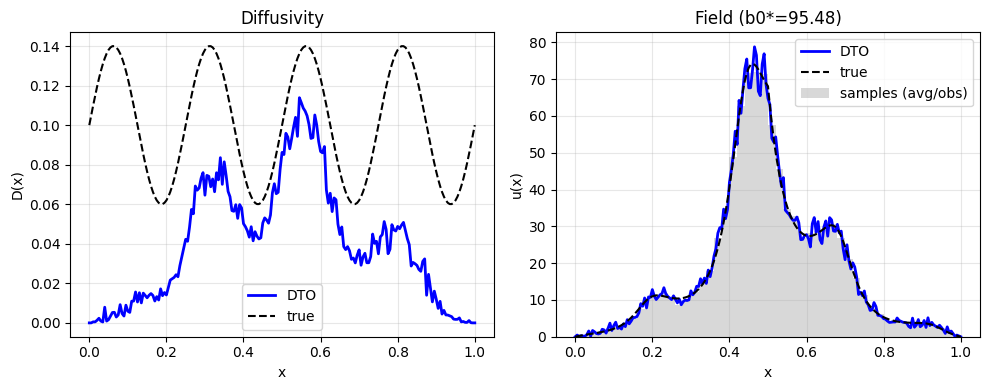

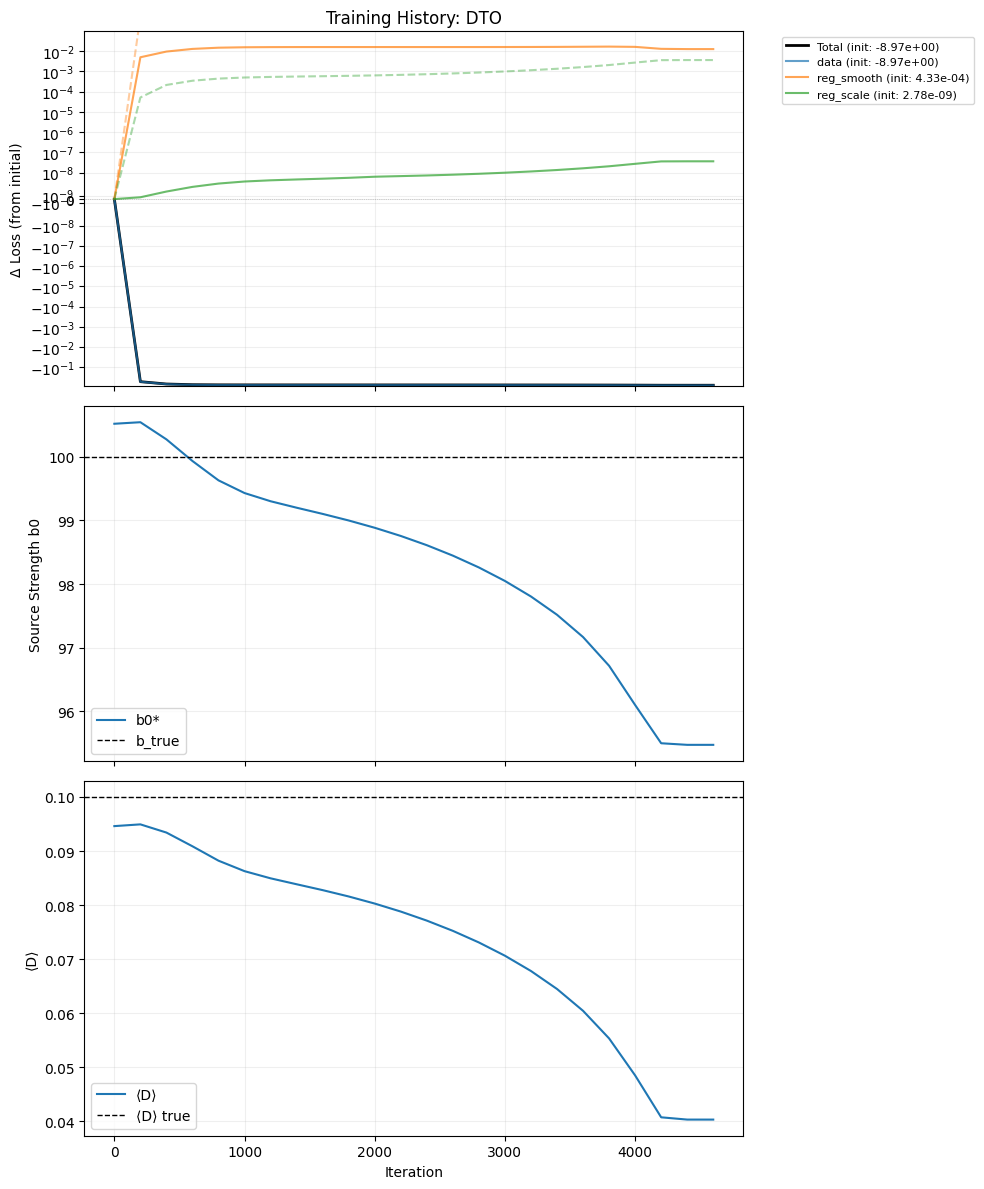

In [10]:

print("\n--- DTO (particles) ---")
dto_solution_ppp = solve(
    problem_ppp,
    method="dto",  # discretize-then-optimize solver
    **{**SHARED_CONFIG, **DTO_PARTICLE_CONFIG},
)


dto_metrics_ppp = dto_solution_ppp.metrics(problem_ppp)
print(f"DTO: particle-mode D(x) rel error = {dto_metrics_ppp['d_rel_error']:.2%}")
dto_solution_ppp.plot(problem_ppp)
diagnostics.plot_training_history(
    "DTO",
    dto_solution_ppp.history,
    problem_ppp.b_true,
    outdir=None,
    mean_d_true=mean_d_true_ppp,
    weights=dto_solution_ppp.weights,
)


### Cell 8: Particle observations (PINN)



--- PINN (particles) ---
[Solve] Method: PINN | α: 0.0 | Mode: particles
[scalar_fit] Starting: d_init=0.068715, mode=particles, max_iters=500
[scalar_fit] iter 0: D=0.168715, loss=-8.850678e+00
[scalar_fit] iter 100: D=0.094629, loss=-8.975103e+00
[scalar_fit] iter 200: D=0.094607, loss=-8.975123e+00
[scalar_fit] iter 300: D=0.094607, loss=-8.975123e+00
[scalar_fit] iter 400: D=0.094607, loss=-8.975123e+00
[scalar_fit] Final: D=0.094607, loss=-8.975123e+00
[PINN] DDI scale: 6.872e-02
[PINN] Scalar fit scale: 9.461e-02
[PINN|pretrain] Iter 00000 | Ltot: 2.475e+01
  Lphys: 2.442e+01 | Lanchor: 3.291e-01
  Lres: 2.432e+00 | Ljump: 1.003e+00
  mean_D: 6.682e-01
[PINN|pretrain] Iter 00200 | Ltot: 1.687e-01
  Lphys: 8.552e-02 | Lanchor: 8.323e-02
  Lres: 2.809e-03 | Ljump: 5.743e-01
  mean_D: 3.549e-01
[PINN|pretrain] Iter 00400 | Ltot: 1.191e-01
  Lphys: 7.489e-02 | Lanchor: 4.422e-02
  Lres: 1.340e-03 | Ljump: 6.149e-01
  mean_D: 2.809e-01
[PINN|pretrain] Iter 00600 | Ltot: 9.456e-02
  L

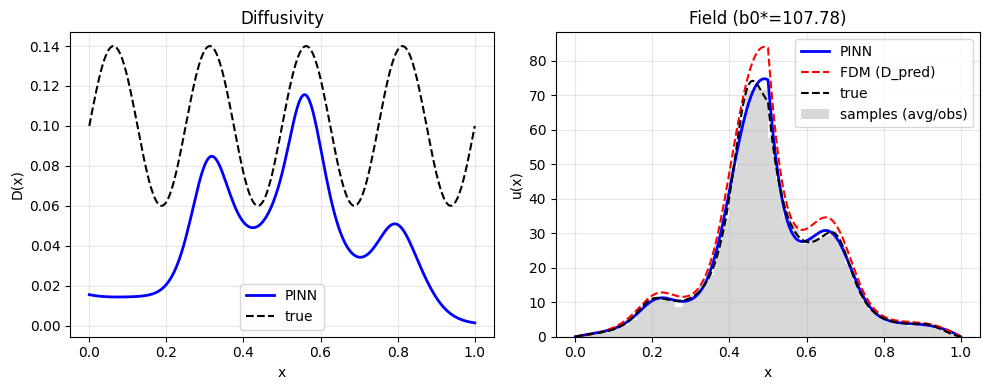

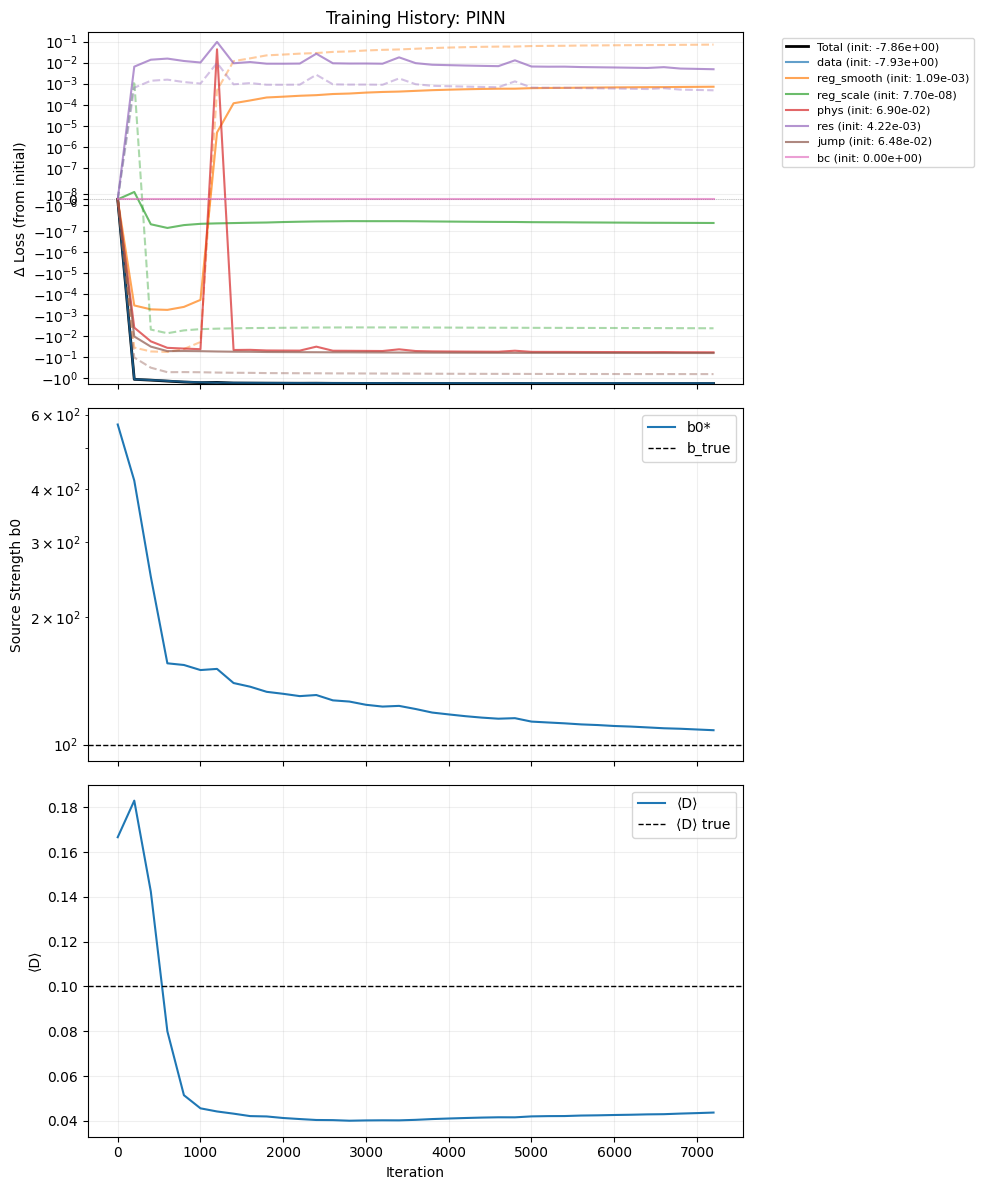

In [11]:
print("\n--- PINN (particles) ---")
pinn_solution_ppp = solve(
    problem_ppp,
    method="pinn",  # physics-informed neural network
    **{**SHARED_CONFIG, **PINN_PARTICLE_CONFIG},
)


pinn_metrics_ppp = pinn_solution_ppp.metrics(problem_ppp)
print(f"PINN: particle-mode D(x) rel error = {pinn_metrics_ppp['d_rel_error']:.2%}")
pinn_solution_ppp.plot(problem_ppp)
diagnostics.plot_training_history(
    "PINN",
    pinn_solution_ppp.history,
    problem_ppp.b_true,
    outdir=None,
    mean_d_true=mean_d_true_ppp,
    weights=pinn_solution_ppp.weights,
)


### Cell 9: Particle observations (BiLO)



--- BiLO (particles) ---
[Solve] Method: BILO | α: 0.0 | Mode: particles
[scalar_fit] Starting: d_init=0.068715, mode=particles, max_iters=500
[scalar_fit] iter 0: D=0.168715, loss=-8.850678e+00
[scalar_fit] iter 100: D=0.094629, loss=-8.975103e+00
[scalar_fit] iter 200: D=0.094607, loss=-8.975123e+00
[scalar_fit] iter 300: D=0.094607, loss=-8.975123e+00
[scalar_fit] iter 400: D=0.094607, loss=-8.975123e+00
[scalar_fit] Final: D=0.094607, loss=-8.975123e+00
[BiLO] DDI scale: 6.872e-02
[BiLO] Scalar fit scale: 9.461e-02
[BiLO|pretrain] Iter 00000 | Ltot: 3.858e+00
  Lanchor: 4.300e-01 | Llower: 3.397e+00 | Lsup: 3.088e-02
  Lres: 2.388e+00 | Ljump: 9.993e-01 | Lrgrad: 9.866e-01 | Ljump_rgrad: 8.102e-08
  mean_D: 7.445e-01
[BiLO|pretrain] Iter 00200 | Ltot: 7.765e-01
  Lanchor: 1.362e-03 | Llower: 7.288e-01 | Lsup: 4.635e-02
  Lres: 4.288e-02 | Ljump: 6.854e-01 | Lrgrad: 2.719e-02 | Ljump_rgrad: 2.168e-02
  mean_D: 1.204e-01
[BiLO|pretrain] Iter 00400 | Ltot: 7.234e-02
  Lanchor: 2.693e

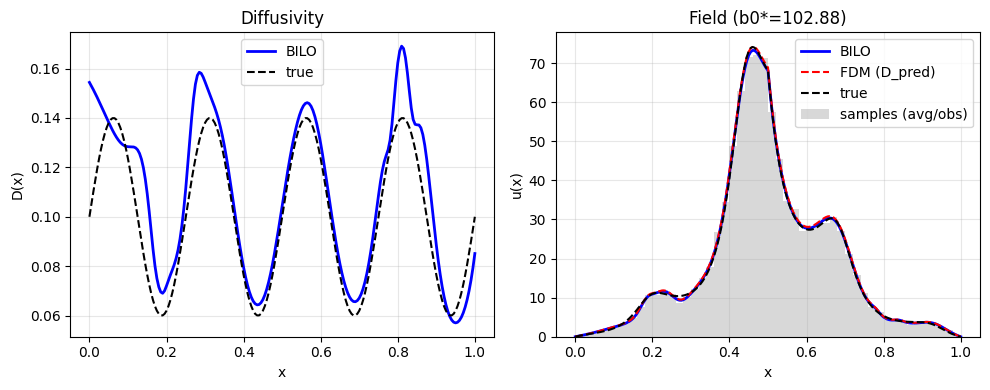

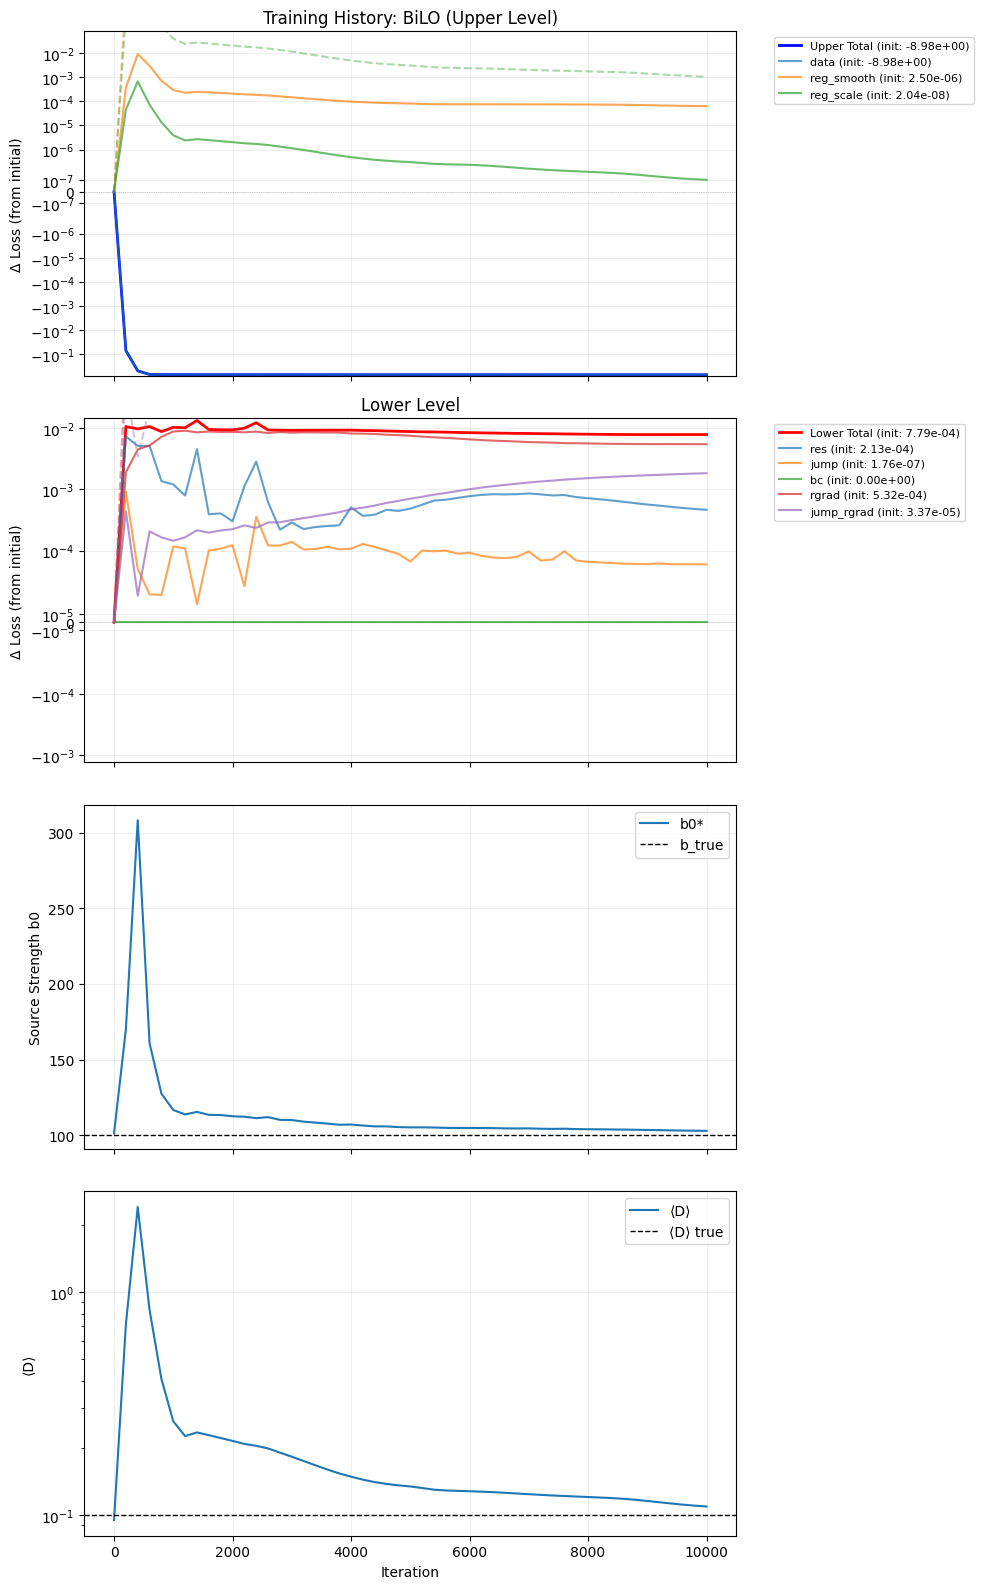

In [12]:
print("\n--- BiLO (particles) ---")
bilo_solution_ppp = solve(
    problem_ppp,
    method="bilo",  # bilevel local operator
    **{**SHARED_CONFIG, **BILO_PARTICLE_CONFIG},
)
bilo_metrics_ppp = bilo_solution_ppp.metrics(problem_ppp)
print(f"BiLO: particle-mode D(x) rel error = {bilo_metrics_ppp['d_rel_error']:.2%}")
bilo_solution_ppp.plot(problem_ppp)
diagnostics.plot_training_history(
    "BiLO",
    bilo_solution_ppp.history,
    problem_ppp.b_true,
    outdir=None,
    mean_d_true=mean_d_true_ppp,
    weights=bilo_solution_ppp.weights,
)
